![alternative text](../logo.png)

# Heat and Cold Spells – heat wave and cold spell days example

This notebook shows how to retrieve **heat and cold spell data** using the `sis-heat-and-cold-spells` dataset, using heat wave days and cold spell days as examples.

In this example, you will:

1. Build and send a data request using a **bounding box** or a **polygon**
2. Decode the CoverageJSON data into an **xarray Dataset**
3. Visualise the data using the EarthKit plots package (Optional)

---

### What are heat and cold spells?

This dataset counts the number of hot and cold spell days per year over Europe, on a 0.1° grid from 1986 to 2085, with each value averaged over a 30-year window. It is derived from a bias-adjusted EURO-CORDEX ensemble of climate projections, and is served either as the ensemble mean or as its standard deviation. Its distinctive field is `definition`: a spell can be counted using a European-wide definition or using the national definitions that individual countries apply. This type of data is used for heat-health planning, energy-demand assessment and climate-risk work.

More information about **available variables** and **request fields** can be found in:
- README and constraints/sis-heat-and-cold-spells.json
- https://cds.climate.copernicus.eu/datasets/sis-heat-and-cold-spells?tab=overview

## Imports and shared settings

In [1]:
# Uncomment and run this cell if you need to install the dependencies
#!pip install -r requirements.txt

In [2]:
#Data requests and decode
import requests
from covjsonkit.api import Covjsonkit

#Data visualisation
import earthkit.plots as ekp

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="earthkit")

# API endpoint template
base_url = 'https://polytope-dss.ecmwf.int/api/v1/dataset/{dataset}/extract/'

headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json',
}

url = base_url.format(dataset='sis-heat-and-cold-spells')


---

## Example 1 – Bounding-box query

A **bounding box** selects all grid points inside a rectangular region defined by two corner coordinates.

In this request, we retrieve **heat wave days** for two scenarios, **RCP4.5** and **RCP8.5**, and compare them at the end of the record (2085).

The bounding box covers **France** and its neighbours (roughly 42°N–51°N, 5°W–8°E). The August 2003 heatwave caused around 15 000 excess deaths in France and some 70 000 across Europe, and is still the benchmark event for European heat-health planning.

Two fields are specific to this dataset: `definition` selects how a spell is counted — here `health_related`, a European-wide definition available over the whole domain — and `ensemble_statistic` picks the ensemble mean or its standard deviation.

The API returns data in **CoverageJSON** format.

### 1.1 Send the request

In [3]:
france_bbox = [[42.0, -5.0], [51.0, 8.0]]   # [lat_min, lon_min], [lat_max, lon_max]

bbox_request45 = {
    'request': {
        'variable': ['heat_wave_days'],
        'experiment': ['rcp4_5'],
        'definition': 'health_related',
        'ensemble_statistic': ['ensemble_members_average'],
    },
    'feature': {
        'type': 'boundingbox',
        # Coordinates are [lat_min, lon_min] and [lat_max, lon_max]
        'coordinates': france_bbox,
    },
}
bbox_request85 = {
    'request': {
        'variable': ['heat_wave_days'],
        'experiment': ['rcp8_5'],
        'definition': 'health_related',
        'ensemble_statistic': ['ensemble_members_average'],
    },
    'feature': {
        'type': 'boundingbox',
        'coordinates': france_bbox,
    },
}

response_bbox45 = requests.post(url, headers=headers, json=bbox_request45)
response_bbox85 = requests.post(url, headers=headers, json=bbox_request85)

#Print the response status code
print('Status RCP4.5:', response_bbox45.status_code)
print('Status RCP8.5:', response_bbox85.status_code)


Status RCP4.5: 200
Status RCP8.5: 200


### 1.2 Decode the response

The module `covjsonkit` converts the downloaded CoverageJSON dataset into an [xarray Dataset](https://docs.xarray.dev/en/stable/), which gives us a labelled overview of the dataset and makes future post-processing straightforward.

In [4]:
decoder_bbox45 = Covjsonkit().decode(response_bbox45.json()); decoder_bbox85 = Covjsonkit().decode(response_bbox85.json())
ds_bbox45 = decoder_bbox45.to_xarray(); ds_bbox85 = decoder_bbox85.to_xarray()
ds_bbox45

<xarray.Dataset> Size: 10MB
Dimensions:        (datetimes: 100, number: 1, steps: 1, points: 11921)
Coordinates:
  * datetimes      (datetimes) <U19 8kB '1986-01-01 00:00:00' ... '2085-01-01...
  * number         (number) int64 8B 0
  * steps          (steps) int64 8B 0
  * points         (points) int64 95kB 0 1 2 3 4 ... 11917 11918 11919 11920
    latitude       (points) float64 95kB 42.0 42.0 42.0 42.0 ... 51.0 51.0 51.0
    longitude      (points) float64 95kB -5.0 -4.9 -4.8 -4.7 ... 7.7 7.8 7.9 8.0
    levelist       (points) float64 95kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Data variables:
    HWD_EU_health  (datetimes, number, steps, points) float64 10MB 3.776 ... ...
Attributes:
    number:   0
    step:     0
    date:     1986-01-01 00:00:00

The variable is named after the definition we asked for: `HWD_EU_health` here, where `country_related` would return `HWD_merged`. The `datetimes` coordinate runs annually from 1986 to 2085, and grid points with no data — sea points here — come back as `-1`.

### 1.3 Visualise the data

We plot the last year of the record for both scenarios.

We use **Earthkit Plots** package to visualise the data.
Please, find more information and documentation of the package here:
https://earthkit-plots.readthedocs.io

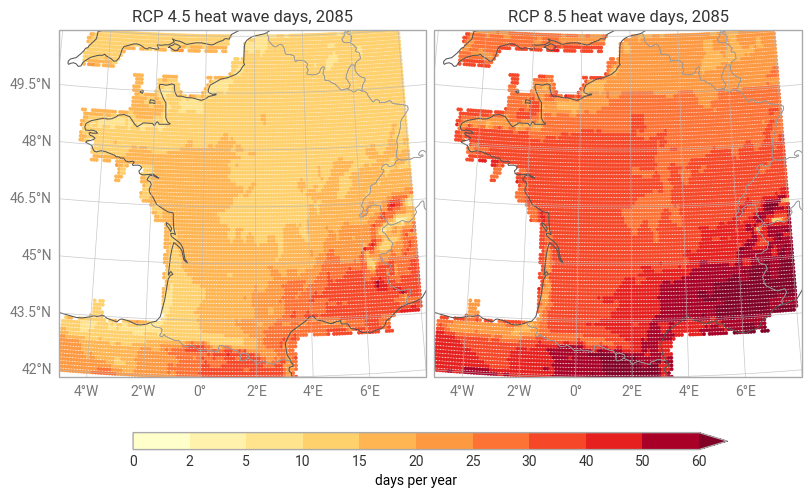

In [5]:
VAR = 'HWD_EU_health'

# Levels start at 0, so the -1 no-data points fall below the scale and are not plotted
heat_levels = [0, 2, 5, 10, 15, 20, 25, 30, 40, 50, 60]

figure = ekp.Figure(rows=1, columns=2, domain=[-5.0, 8.0, 42.0, 51.0])

for ds, scenario in [(ds_bbox45, 'RCP 4.5'), (ds_bbox85, 'RCP 8.5')]:
    ax = figure.add_map()
    ax.point_cloud(ds[VAR].isel(datetimes=-1, number=0, steps=0),
        x=ds['longitude'],
        y=ds['latitude'],
        s=5,
        style=ekp.Style(levels=heat_levels, colors='YlOrRd', extend='max'))
    ax.title(f'{scenario} heat wave days, 2085')

figure.coastlines()
figure.borders()
figure.gridlines()
figure.legend(label='days per year')
figure.show()

Under RCP8.5 the whole country shifts up the colour scale, and the Mediterranean south-east — the Rhône valley and the coast — reaches 40 heat wave days a year and more.

---

## Example 2 – Polygon query

A **polygon** selects grid points inside an arbitrary shape. This is useful when
your area of interest follows administrative boundaries, a river catchment, or
any non-rectangular outline.

Rules for polygon coordinates:

- Each point is `[lat, lon]`
- The polygon must be **closed**: the first and last point must be identical
- At least 4 points are needed (3 unique corners + the closing repeat)

The polygon below traces **Finland**, and we switch to **cold spell days** under RCP8.5, comparing the start of the record (1986) with its end (2085). Finland's lowest temperature on record, −51.5 °C, was measured at Kittilä in Lapland in January 1999.

`cold_spell_days` is only available with `definition: country_related`, which applies each country's own national definition and therefore only returns data where such a definition exists. Finland is one of those countries; over most of Europe the same request comes back filled with `-1`.

### 2.1 Send the request

In [6]:
# Closed polygon of [lat, lon] pairs - first point must equal last point
finland_polygon = [
    [60.40, 22.10],   # Turku, south-west coast
    [59.95, 23.40],   # Hanko, southernmost point
    [60.25, 25.00],   # Helsinki
    [60.45, 26.50],
    [60.55, 27.80],   # Russian border on the Gulf of Finland
    [61.55, 29.50],
    [62.50, 31.30],
    [63.70, 31.20],
    [64.80, 30.10],
    [65.70, 29.80],   # Kuusamo
    [66.50, 29.50],
    [67.40, 29.30],
    [68.20, 28.50],   # Inari
    [69.10, 28.80],
    [69.90, 27.00],   # Utsjoki, northernmost point
    [69.30, 25.80],
    [68.80, 23.00],   # three-country cairn
    [68.35, 22.50],
    [67.50, 23.60],   # Torne river, Swedish border
    [66.50, 23.90],
    [65.80, 24.15],   # Tornio
    [65.00, 25.40],   # Oulu, Gulf of Bothnia
    [64.00, 23.50],
    [63.10, 21.50],   # Vaasa
    [62.00, 21.20],
    [61.10, 21.50],
    [60.40, 22.10],   # close polygon
]

polygon_request = {
    'request': {
        'variable': ['cold_spell_days'],
        'experiment': ['rcp8_5'],
        'definition': 'country_related',
        'ensemble_statistic': ['ensemble_members_average'],
    },
    'feature': {
        'type': 'polygon',
        'coordinates': finland_polygon,
    },
}

response_poly = requests.post(url, headers=headers, json=polygon_request)

# Print the response status code
print('Status:', response_poly.status_code)


Status: 200


### 2.2 Decode the response

As in the previous example, we use `covjsonkit` module to convert the downloaded CoverageJSON dataset into an xarray.

In [7]:
decoder_poly = Covjsonkit().decode(response_poly.json())
ds_poly = decoder_poly.to_xarray()
ds_poly

<xarray.Dataset> Size: 5MB
Dimensions:     (datetimes: 100, number: 1, steps: 1, points: 6112)
Coordinates:
  * datetimes   (datetimes) <U19 8kB '1986-01-01 00:00:00' ... '2085-01-01 00...
  * number      (number) int64 8B 0
  * steps       (steps) int64 8B 0
  * points      (points) int64 49kB 0 1 2 3 4 5 ... 6107 6108 6109 6110 6111
    latitude    (points) float64 49kB 60.0 60.0 60.0 60.0 ... 69.8 69.8 69.8
    longitude   (points) float64 49kB 23.3 23.4 23.5 23.6 ... 27.0 27.1 27.2
    levelist    (points) float64 49kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Data variables:
    CSD_merged  (datetimes, number, steps, points) float64 5MB 6.703 ... 0.2853
Attributes:
    number:   0
    step:     0
    date:     1986-01-01 00:00:00

Only the grid points inside the polygon are returned, and the variable is now `CSD_merged` — the merged national definitions.

### 2.3 Visualise the data

The two panels share one colour scale, which is what makes the change between them readable. As in Example 1, the levels start at `0`, so the `-1` no-data points are left off the map.

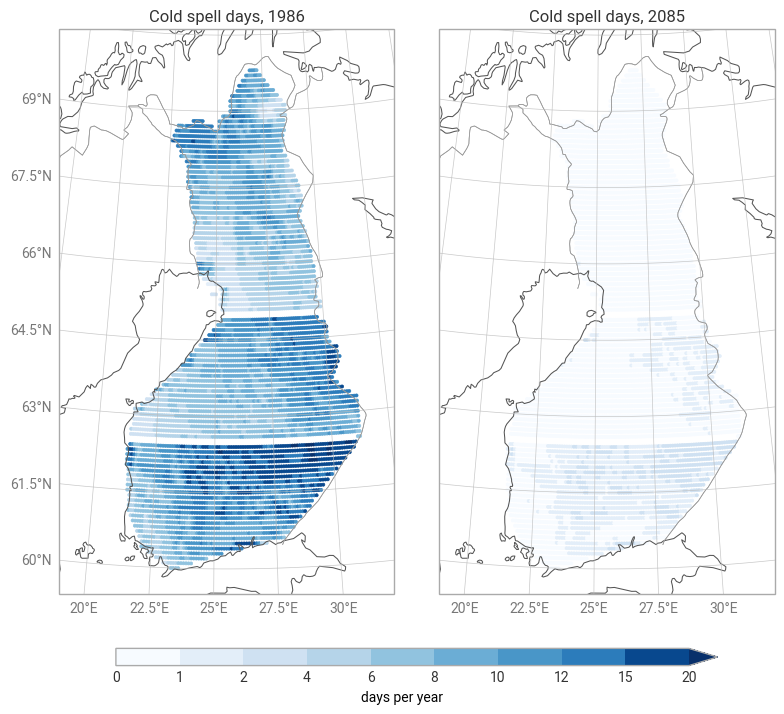

In [8]:
VAR_CSD = 'CSD_merged'

cold_levels = [0, 1, 2, 4, 6, 8, 10, 12, 15, 20]

figure = ekp.Figure(rows=1, columns=2, domain=[19.0, 32.0, 59.5, 70.5])

for year, i in [('1986', 0), ('2085', -1)]:
    ax = figure.add_map()
    ax.point_cloud(ds_poly[VAR_CSD].isel(datetimes=i, number=0, steps=0),
        x=ds_poly['longitude'],
        y=ds_poly['latitude'],
        s=5,
        style=ekp.Style(levels=cold_levels, colors='Blues', extend='max'))
    ax.title(f'Cold spell days, {year}')

figure.coastlines()
figure.borders()
figure.gridlines()
figure.legend(label='days per year')
figure.show()

Cold spell days almost disappear: from around nine a year in 1986 to well under one by 2085, on the same colour scale.

The map also shows abrupt horizontal steps, near 62.5°N and 65°N, where the count drops to a lower value and then climbs again. These are boundaries of the regions the national definition is applied over, not a climate signal — `country_related` is a merged administrative product, so it is reliable for the change over time but should not be read as a smooth spatial field.

---

## Next steps

Now that you can retrieve the data, here are some things to try next:

- **Compare definitions** – request `heat_wave_days` with `definition: 'country_related'` over the same area and see how much the national definitions change the count
- **Look at the ensemble spread** – switch `ensemble_statistic` to `ensemble_members_standard_deviation` to see how much the projections disagree
- **Plot a time series** – each request already returns all 100 years, so a spatial average over `points` gives the full 1986–2085 trajectory
- **Swap the scenario** – run the cold spell example under `rcp4_5` and compare it with RCP8.5
- **Use a real boundary** – load a country shapefile and convert it to a polygon for the API

Please see the constraints file, which contains the valid values for the dataset.